<a href="https://colab.research.google.com/github/joaodutraramires-glitch/DIO-DESAFIO-PROJETO/blob/main/Detec%C3%A7%C3%A3o_de_Anomalias_em_Transa%C3%A7%C3%B5es_em_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dados = {
    "id_transacao": [1, 2, 3, 4, 5, 6, 7, 8],
    "cliente_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "valor": [50.00, 120.50, 35.90, 5000.00, 80.00, 25.00, 3000.00, 60.00],
    "hora": [14, 10, 16, 3, 18, 22, 2, 11],
    "quantidade_transacoes_24h": [2, 3, 1, 20, 4, 2, 18, 1],
    "canal": ["app", "web", "pix", "web", "app", "pix", "app", "caixa_eletronico"],
    "cidade": ["Porto Alegre", "Rio Grande", "Pelotas", "Cidade Desconhecida", "Porto Alegre", "Rio Grande", "Cidade Desconhecida", "Caxias do Sul"]
}


In [4]:
df_csv = pd.DataFrame(dados)
df_csv.to_csv("transacoes.csv", index=False)
print("Arquivo transacoes.csv criado com sucesso!")

df = pd.read_csv("transacoes.csv")
df.head()

print("Quantidade de linhas e colunas:", df.shape)
df.info()
df.describe()


Arquivo transacoes.csv criado com sucesso!
Quantidade de linhas e colunas: (8, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_transacao               8 non-null      int64  
 1   cliente_id                 8 non-null      int64  
 2   valor                      8 non-null      float64
 3   hora                       8 non-null      int64  
 4   quantidade_transacoes_24h  8 non-null      int64  
 5   canal                      8 non-null      object 
 6   cidade                     8 non-null      object 
dtypes: float64(1), int64(4), object(2)
memory usage: 580.0+ bytes


,id_transacao,cliente_id,valor,hora,quantidade_transacoes_24h
count,8.00000,8.00000,8.000000,8.000000,8.000000
mean,4.50000,104.50000,1046.425000,12.000000,6.375000
std,2.44949,2.44949,1899.958338,6.989788,7.872874
min,1.00000,101.00000,25.000000,2.000000,1.000000
25%,2.75000,102.75000,46.475000,8.250000,1.750000
50%,4.50000,104.50000,70.000000,12.500000,2.500000
75%,6.25000,106.25000,840.375000,16.500000,7.500000
max,8.00000,108.00000,5000.000000,22.000000,20.000000


In [5]:
q1 = df["valor"].quantile(0.25)
q3 = df["valor"].quantile(0.75)
iqr = q3 - q1

limite_valor_alto = q3 + 1.5 * iqr
print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Limite para valor anômalo:", round(limite_valor_alto, 2))


Q1: 46.48
Q3: 840.38
IQR: 793.9
Limite para valor anômalo: 2031.22


In [6]:
df["anomalia_valor"] = df["valor"] > limite_valor_alto
df["anomalia_frequencia"] = df["quantidade_transacoes_24h"] >= 15
df["anomalia_horario"] = df["hora"].between(0, 5)
df["anomalia_cidade"] = df["cidade"].str.lower().str.contains("desconhecida")

df["pontuacao_risco"] = (
    df["anomalia_valor"].astype(int) +
    df["anomalia_frequencia"].astype(int) +
    df["anomalia_horario"].astype(int) +
    df["anomalia_cidade"].astype(int)
)

In [7]:
df["suspeita"] = df["pontuacao_risco"] >= 1

df.head()

transacoes_suspeitas = df[df["suspeita"]].copy()

colunas_resultado = [
    "id_transacao",
    "cliente_id",
    "valor",
    "hora",
    "quantidade_transacoes_24h",
    "canal",
    "cidade",
    "pontuacao_risco",
    "anomalia_valor",
    "anomalia_frequencia",
    "anomalia_horario",
    "anomalia_cidade"
]

transacoes_suspeitas[colunas_resultado].sort_values(
    by=["pontuacao_risco", "valor"],
    ascending=False
)


,id_transacao,cliente_id,valor,hora,quantidade_transacoes_24h,canal,cidade,pontuacao_risco,anomalia_valor,anomalia_frequencia,anomalia_horario,anomalia_cidade
3,4,104,5000.0,3,20,web,Cidade Desconhecida,4,True,True,True,True
6,7,107,3000.0,2,18,app,Cidade Desconhecida,4,True,True,True,True


suspeita
Normal      6
Suspeita    2
Name: count, dtype: int64
Percentual de transações suspeitas: 25.00%


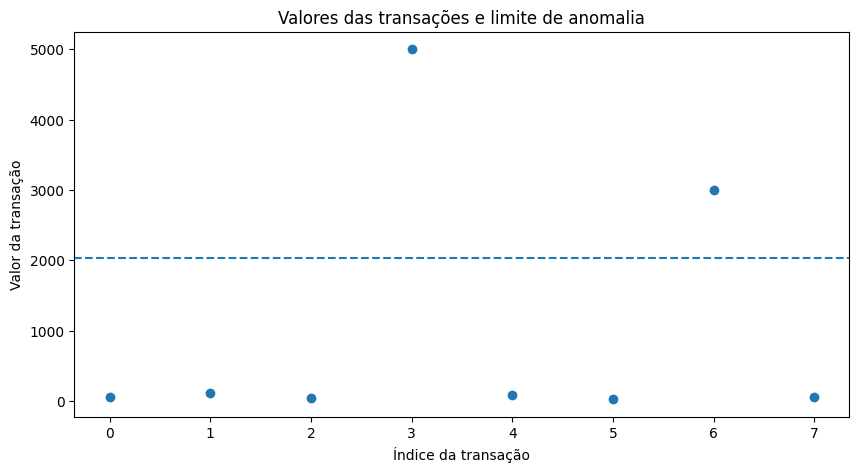

Arquivo gerado: transacoes_classificadas.csv


In [8]:
resumo = df["suspeita"].value_counts().rename(index={False: "Normal", True: "Suspeita"})
print(resumo)

percentual_suspeitas = df["suspeita"].mean() * 100
print(f"Percentual de transações suspeitas: {percentual_suspeitas:.2f}%")

plt.figure(figsize=(10, 5))
plt.scatter(df.index, df["valor"])
plt.axhline(limite_valor_alto, linestyle="--")
plt.title("Valores das transações e limite de anomalia")
plt.xlabel("Índice da transação")
plt.ylabel("Valor da transação")
plt.show()

df.to_csv("transacoes_classificadas.csv", index=False, encoding="utf-8")
print("Arquivo gerado: transacoes_classificadas.csv")